<a href="https://colab.research.google.com/github/yinkatanko-a11y/PensComplaintProject/blob/main/performance_copy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Importing Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#Arranging Settings
pd.set_option('display.max_column', 100)
sns.set_theme(style="darkgrid")

In [ ]:
#Importing the data
data = pd.read_csv('student-por.csv')
data.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,0,yes,no,no,no,yes,yes,yes,no,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,no,yes,yes,yes,yes,yes,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,no,no,yes,yes,no,no,4,3,2,1,2,5,0,11,13,13


In [ ]:
data.columns

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='object')

In [ ]:
# Droping columns not applicable to this project
data = data.drop(['school', 'paid', 'romantic', 'Dalc', 'Walc'], axis =1)

In [ ]:
data.head()

,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,activities,nursery,higher,internet,famrel,freetime,goout,health,absences,G1,G2,G3
0,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,yes,yes,no,4,3,4,3,4,0,11,11
1,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,yes,yes,5,3,3,3,2,9,11,11
2,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,0,yes,no,no,yes,yes,yes,4,3,2,3,6,12,13,12
3,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,yes,yes,yes,yes,3,2,2,5,0,14,14,14
4,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,no,yes,yes,no,4,3,2,5,0,11,13,13


In [ ]:
bins = pd.IntervalIndex.from_tuples([(0, 9), (9, 11), (11, 13), (13, 15), (15, 20)])
#levels = ['fail', 'sufficient', 'satisfactory', 'good', 'excellent']
levels = ['F', 'D', 'C', 'B', 'A']
data['grade_rank'] = np.array(levels)[pd.cut(data['G3'], bins = bins).cat.codes]
data.head()

,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,activities,nursery,higher,internet,famrel,freetime,goout,health,absences,G1,G2,G3,grade_rank
0,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,yes,yes,no,4,3,4,3,4,0,11,11,D
1,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,yes,yes,5,3,3,3,2,9,11,11,D
2,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,0,yes,no,no,yes,yes,yes,4,3,2,3,6,12,13,12,C
3,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,yes,yes,yes,yes,3,2,2,5,0,14,14,14,B
4,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,no,yes,yes,no,4,3,2,5,0,11,13,13,C


In [ ]:
data.shape

(649, 29)

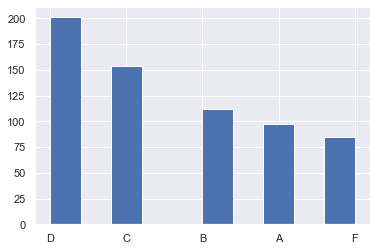

In [ ]:
#Viewing Data Distribution
data['grade_rank'].hist()

In [ ]:
data.sex.value_counts()

F    383
M    266
Name: sex, dtype: int64

In [ ]:
data.isnull().sum()

sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
activities    0
nursery       0
higher        0
internet      0
famrel        0
freetime      0
goout         0
health        0
absences      0
G1            0
G2            0
G3            0
grade_rank    0
dtype: int64

In [ ]:
np.array(levels)

array(['F', 'D', 'C', 'B', 'A'], dtype='<U1')

In [ ]:
#corrolation plot
def plot_corr_map(data, **kwargs):
    _, ax = plt.subplots(figsize=(35, 35))
    sns.heatmap(data.corr(), ax = ax, **kwargs)
    ax.set_title('Correlation heatmap')
    plt.show()


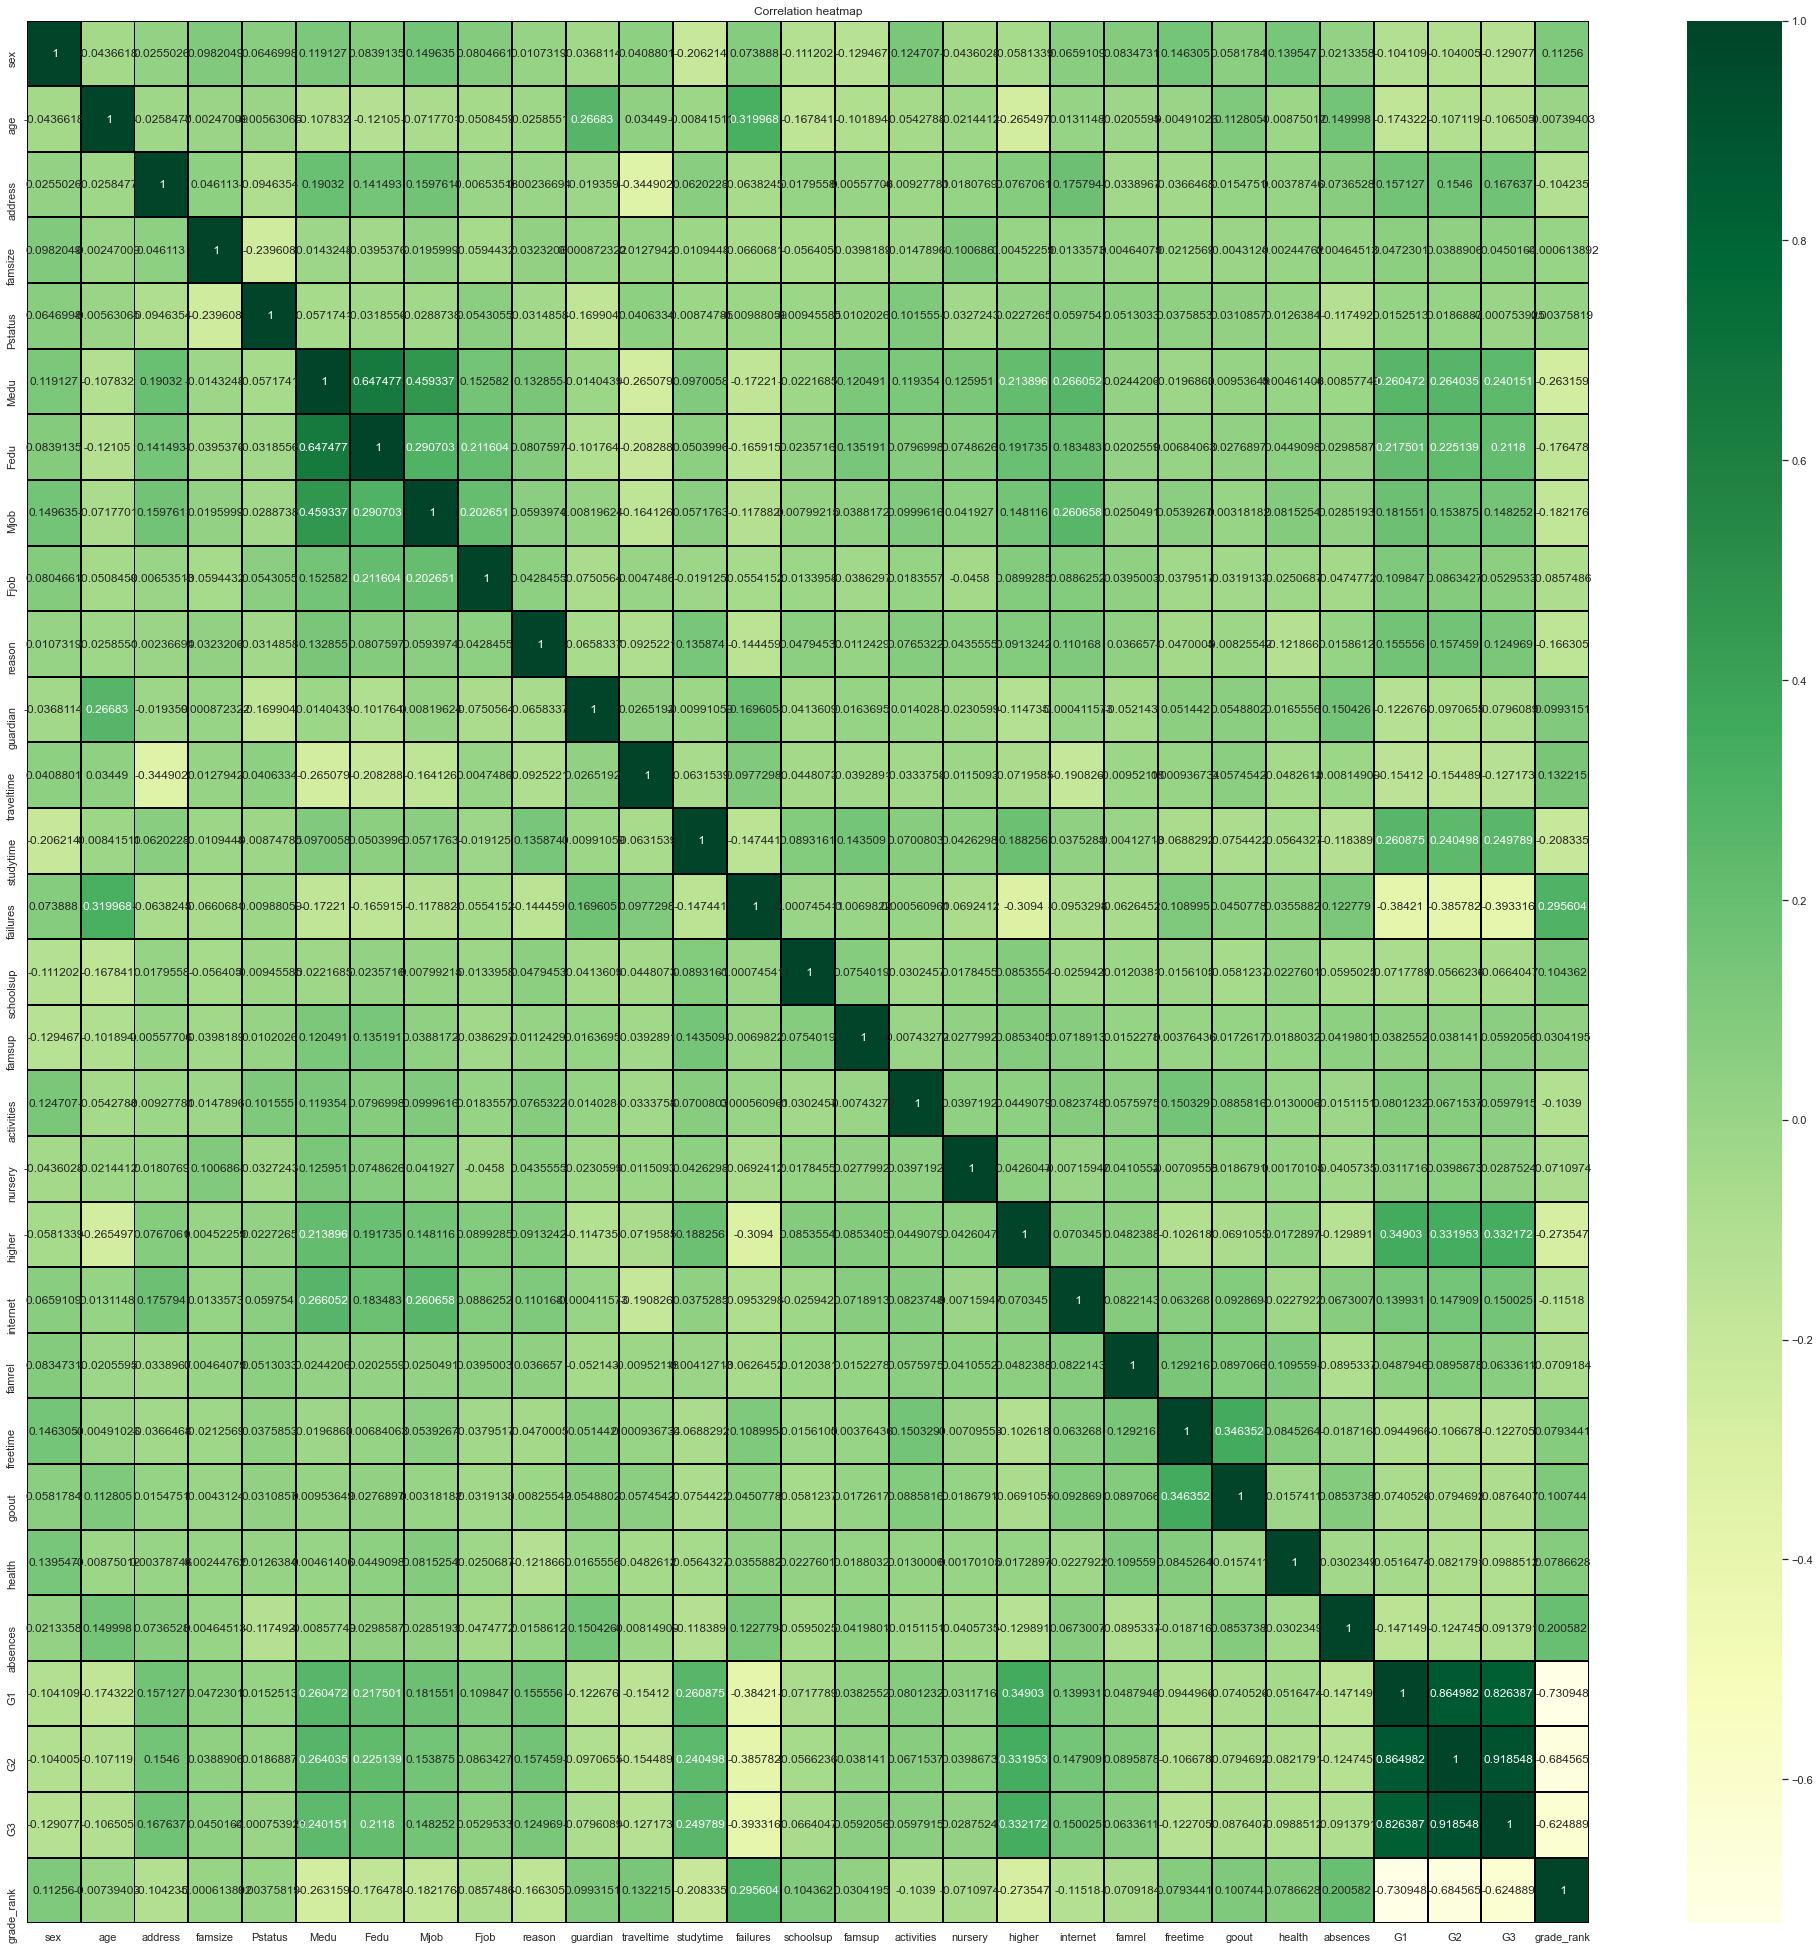

In [ ]:
from sklearn.preprocessing import OrdinalEncoder
params = {'annot':True, 'fmt': '2g', 'cmap': 'YlGn', 'linewidths': 1, 'linecolor': 'black'}
ordinal = OrdinalEncoder()
columns = data.select_dtypes('object').columns
data_ordinal = data.copy()
data_ordinal[columns] = ordinal.fit_transform(data_ordinal[columns])
plot_corr_map(data_ordinal, **params)

In [ ]:
data_ordinal.iloc[:, :-2].corr().min()

sex          -0.206214
age          -0.265497
address      -0.344902
famsize      -0.239608
Pstatus      -0.239608
Medu         -0.265079
Fedu         -0.208288
Mjob         -0.164126
Fjob         -0.075056
reason       -0.144459
guardian     -0.169904
traveltime   -0.344902
studytime    -0.206214
failures     -0.385782
schoolsup    -0.167841
famsup       -0.129467
activities   -0.054279
nursery      -0.069241
higher       -0.309400
internet     -0.190826
famrel       -0.089534
freetime     -0.106678
goout        -0.079469
health       -0.121866
absences     -0.147149
G1           -0.384210
G2           -0.385782
dtype: float64

In [ ]:
# plotting categorical columns
def plot_categorical(cat_columns):
    nrows, ncols = cat_columns.shape[1], 3
    _, axes = plt.subplots(nrows, ncols, figsize=(25, 85))

    for idx, col in enumerate(cat_columns):
        ax = axes[idx]
        sns.countplot(data=data, x='grade_rank', hue=col, ax=ax[0])

        sns.countplot(data=data, x=col, ax=ax[1])

        sns.boxplot(data=data, y='G3', x= col, hue=col, ax=ax[2])

        #plt.show()


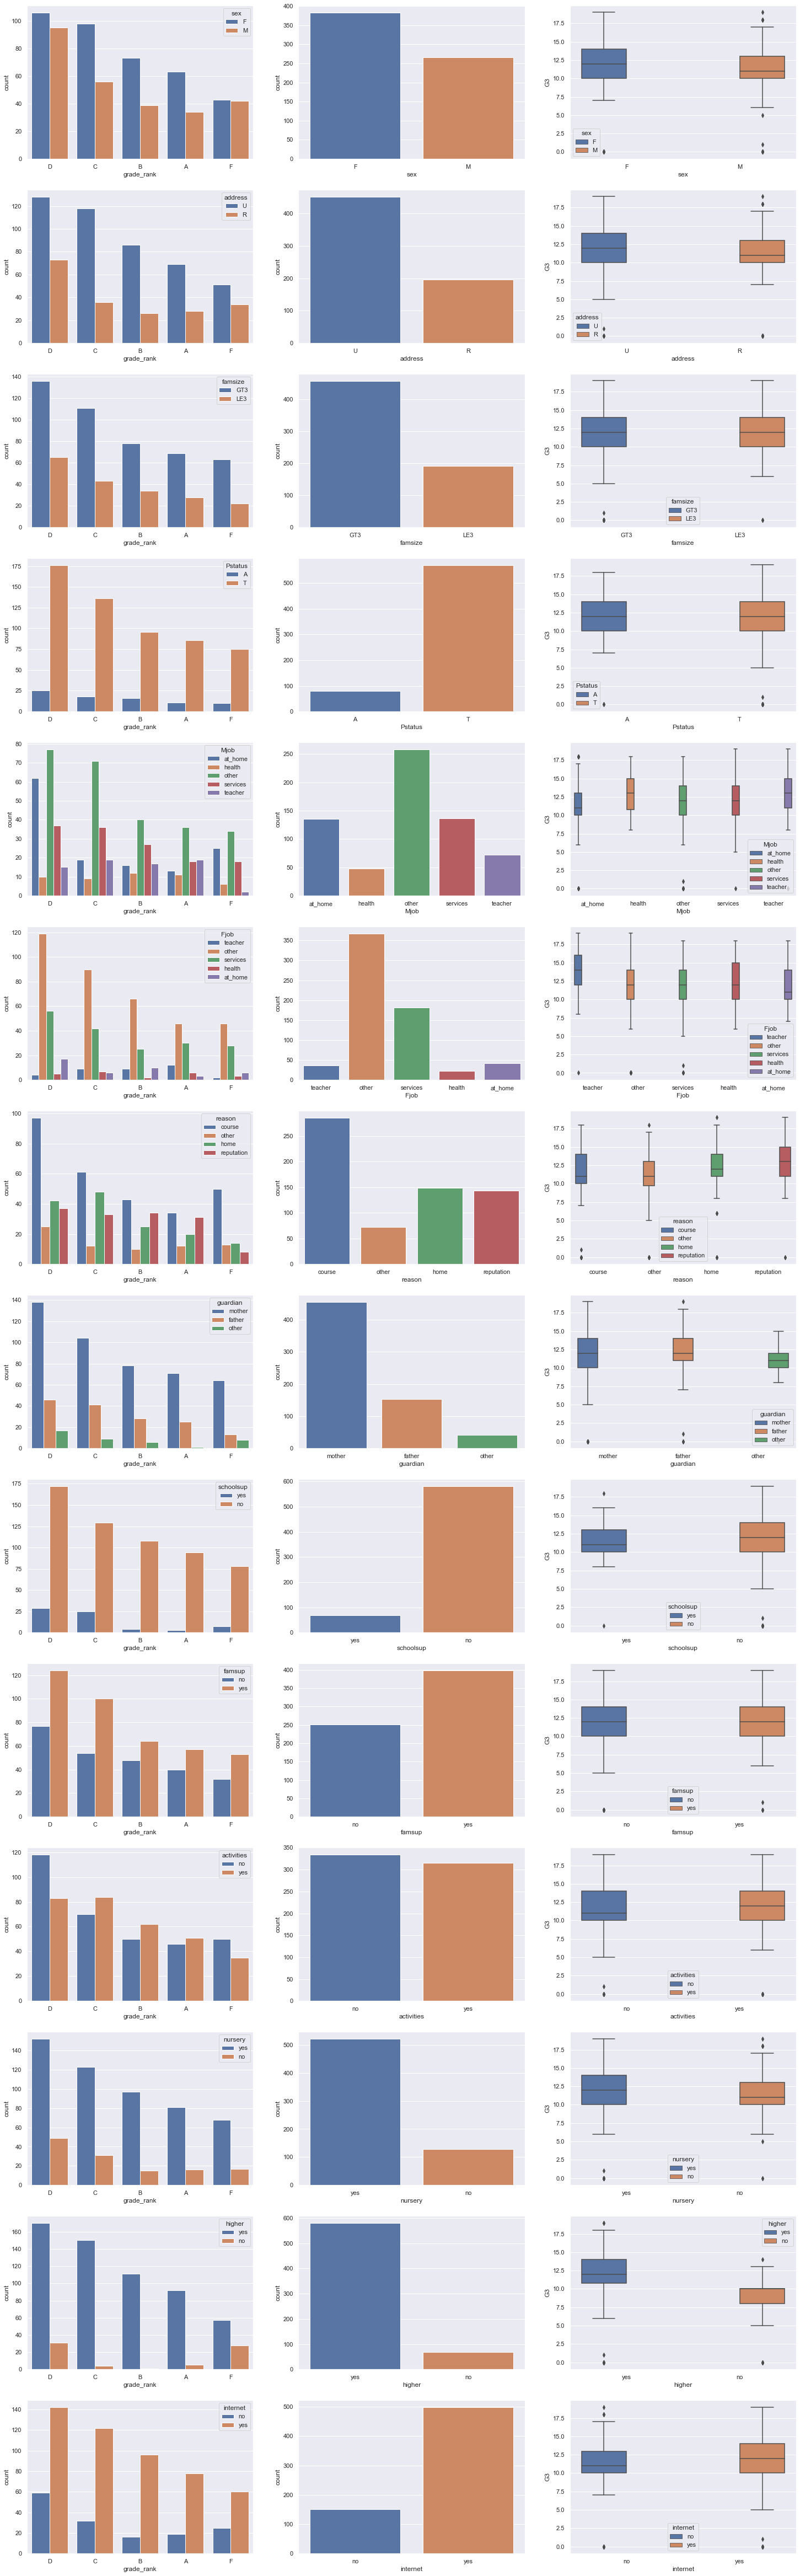

In [ ]:
cat_cols = data.select_dtypes(include='object')
cat_cols = cat_cols.drop('grade_rank', axis = 1)
plot_categorical(cat_cols)

In [ ]:
cat_cols

,sex,address,famsize,Pstatus,Mjob,Fjob,reason,guardian,schoolsup,famsup,activities,nursery,higher,internet
0,F,U,GT3,A,at_home,teacher,course,mother,yes,no,no,yes,yes,no
1,F,U,GT3,T,at_home,other,course,father,no,yes,no,no,yes,yes
2,F,U,LE3,T,at_home,other,other,mother,yes,no,no,yes,yes,yes
3,F,U,GT3,T,health,services,home,mother,no,yes,yes,yes,yes,yes
4,F,U,GT3,T,other,other,home,father,no,yes,no,yes,yes,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
644,F,R,GT3,T,services,other,course,mother,no,no,yes,no,yes,yes
645,F,U,LE3,T,teacher,services,course,mother,no,yes,no,yes,yes,yes
646,F,U,GT3,T,other,other,course,mother,no,no,yes,yes,yes,no
647,M,U,LE3,T,services,services,course,mother,no,no,no,no,yes,yes


In [ ]:
#getting the value of class of studnets with respect to their total number
cat_cols = data.select_dtypes(include='object')
for idx, col in enumerate(cat_cols):
    for val1, val2 in zip (range(0, (len(cat_cols[col].value_counts())+1)*5, 5), range(5, (len(cat_cols[col].value_counts())+1)*5, 5)):
        print(val1,val2, col)

0 5 sex
5 10 sex
0 5 address
5 10 address
0 5 famsize
5 10 famsize
0 5 Pstatus
5 10 Pstatus
0 5 Mjob
5 10 Mjob
10 15 Mjob
15 20 Mjob
20 25 Mjob
0 5 Fjob
5 10 Fjob
10 15 Fjob
15 20 Fjob
20 25 Fjob
0 5 reason
5 10 reason
10 15 reason
15 20 reason
0 5 guardian
5 10 guardian
10 15 guardian
0 5 schoolsup
5 10 schoolsup
0 5 famsup
5 10 famsup
0 5 activities
5 10 activities
0 5 nursery
5 10 nursery
0 5 higher
5 10 higher
0 5 internet
5 10 internet
0 5 grade_rank
5 10 grade_rank
10 15 grade_rank
15 20 grade_rank
20 25 grade_rank


In [ ]:
#getting the value of class of studnets with respect to their total number
cat_cols = data.select_dtypes(include='object')
for idx, col in enumerate(cat_cols):
    for val1, val2 in zip (range(0, (len(cat_cols[col].value_counts())+1)*5, 5), range(5, (len(cat_cols[col].value_counts())+1)*5, 5)):
        print(cat_cols.groupby(col)['grade_rank'].value_counts()[val1:val2]/ cat_cols.groupby(col)['grade_rank'].value_counts()[val1:val2].sum())
    print('\n\n')


sex  grade_rank
F    D             0.276762
     C             0.255875
     B             0.190601
     A             0.164491
     F             0.112272
Name: grade_rank, dtype: float64
sex  grade_rank
M    D             0.357143
     C             0.210526
     F             0.157895
     B             0.146617
     A             0.127820
Name: grade_rank, dtype: float64



address  grade_rank
R        D             0.370558
         C             0.182741
         F             0.172589
         A             0.142132
         B             0.131980
Name: grade_rank, dtype: float64
address  grade_rank
U        D             0.283186
         C             0.261062
         B             0.190265
         A             0.152655
         F             0.112832
Name: grade_rank, dtype: float64



famsize  grade_rank
GT3      D             0.297593
         C             0.242888
         B             0.170678
         A             0.150985
         F             0.137856
Name: grad

### PLoting the non-categorical columns

In [ ]:
def plot_non_cat(non_categorical_columns):
    nrows, ncols = non_categorical_columns.shape[1], 2
    _, axes = plt.subplots(nrows, ncols, figsize= (20, 100))

    for idx, col in enumerate(non_categorical_columns):
        ax=axes[idx]
        sns.scatterplot(data=data, x=col, y= 'G3', hue = 'grade_rank', ax = ax[0])
        ax[0].legend(loc = 'upper center',
                     bbox_to_anchor= (0.5, 1.07), ncol= 5, fancybox= True, shadow= True)

        sns.boxplot(data = data, x=col, y= 'G3', ax=ax[1])


In [ ]:
data.G3.std()

3.2306562428048045

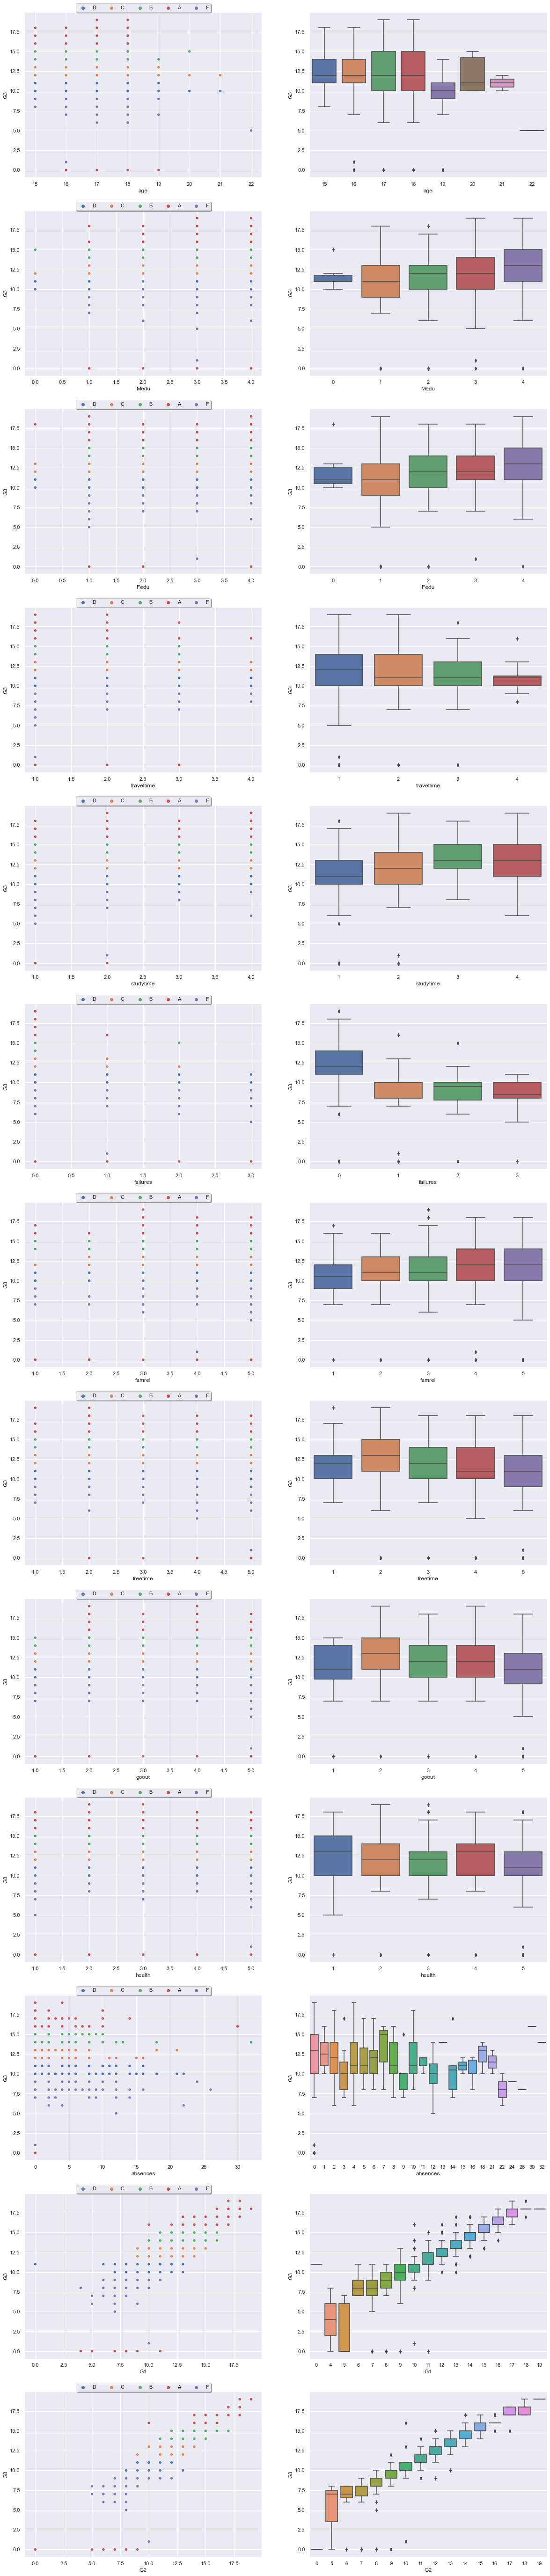

In [ ]:
non_cat_cols= data.select_dtypes(['int64', 'float64'])
non_cat_cols = non_cat_cols.drop('G3', axis = 1)
plot_non_cat(non_cat_cols)

## Preprocessing and Feature Engineering

In [ ]:
# removing outlier
data.head()

,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,activities,nursery,higher,internet,famrel,freetime,goout,health,absences,G1,G2,G3,grade_rank
0,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,yes,yes,no,4,3,4,3,4,0,11,11,D
1,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,yes,yes,5,3,3,3,2,9,11,11,D
2,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,0,yes,no,no,yes,yes,yes,4,3,2,3,6,12,13,12,C
3,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,yes,yes,yes,yes,3,2,2,5,0,14,14,14,B
4,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,no,yes,yes,no,4,3,2,5,0,11,13,13,C


In [ ]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

new_data   = data.copy()
cat_cols = new_data.select_dtypes(include='object')
for idx, col in enumerate(cat_cols):
    new_data[col] = encoder.fit_transform(new_data[col])

new_data.head()

,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,activities,nursery,higher,internet,famrel,freetime,goout,health,absences,G1,G2,G3,grade_rank
0,0,18,1,0,0,4,4,0,4,0,1,2,2,0,1,0,0,1,1,0,4,3,4,3,4,0,11,11,3
1,0,17,1,0,1,1,1,0,2,0,0,1,2,0,0,1,0,0,1,1,5,3,3,3,2,9,11,11,3
2,0,15,1,1,1,1,1,0,2,2,1,1,2,0,1,0,0,1,1,1,4,3,2,3,6,12,13,12,2
3,0,15,1,0,1,4,2,1,3,1,1,1,3,0,0,1,1,1,1,1,3,2,2,5,0,14,14,14,1
4,0,16,1,0,1,3,3,2,2,1,0,1,2,0,0,1,0,1,1,0,4,3,2,5,0,11,13,13,2


In [ ]:
data.head()

,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,activities,nursery,higher,internet,famrel,freetime,goout,health,absences,G1,G2,G3,grade_rank
0,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,yes,yes,no,4,3,4,3,4,0,11,11,D
1,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,yes,yes,5,3,3,3,2,9,11,11,D
2,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,0,yes,no,no,yes,yes,yes,4,3,2,3,6,12,13,12,C
3,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,yes,yes,yes,yes,3,2,2,5,0,14,14,14,B
4,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,no,yes,yes,no,4,3,2,5,0,11,13,13,C


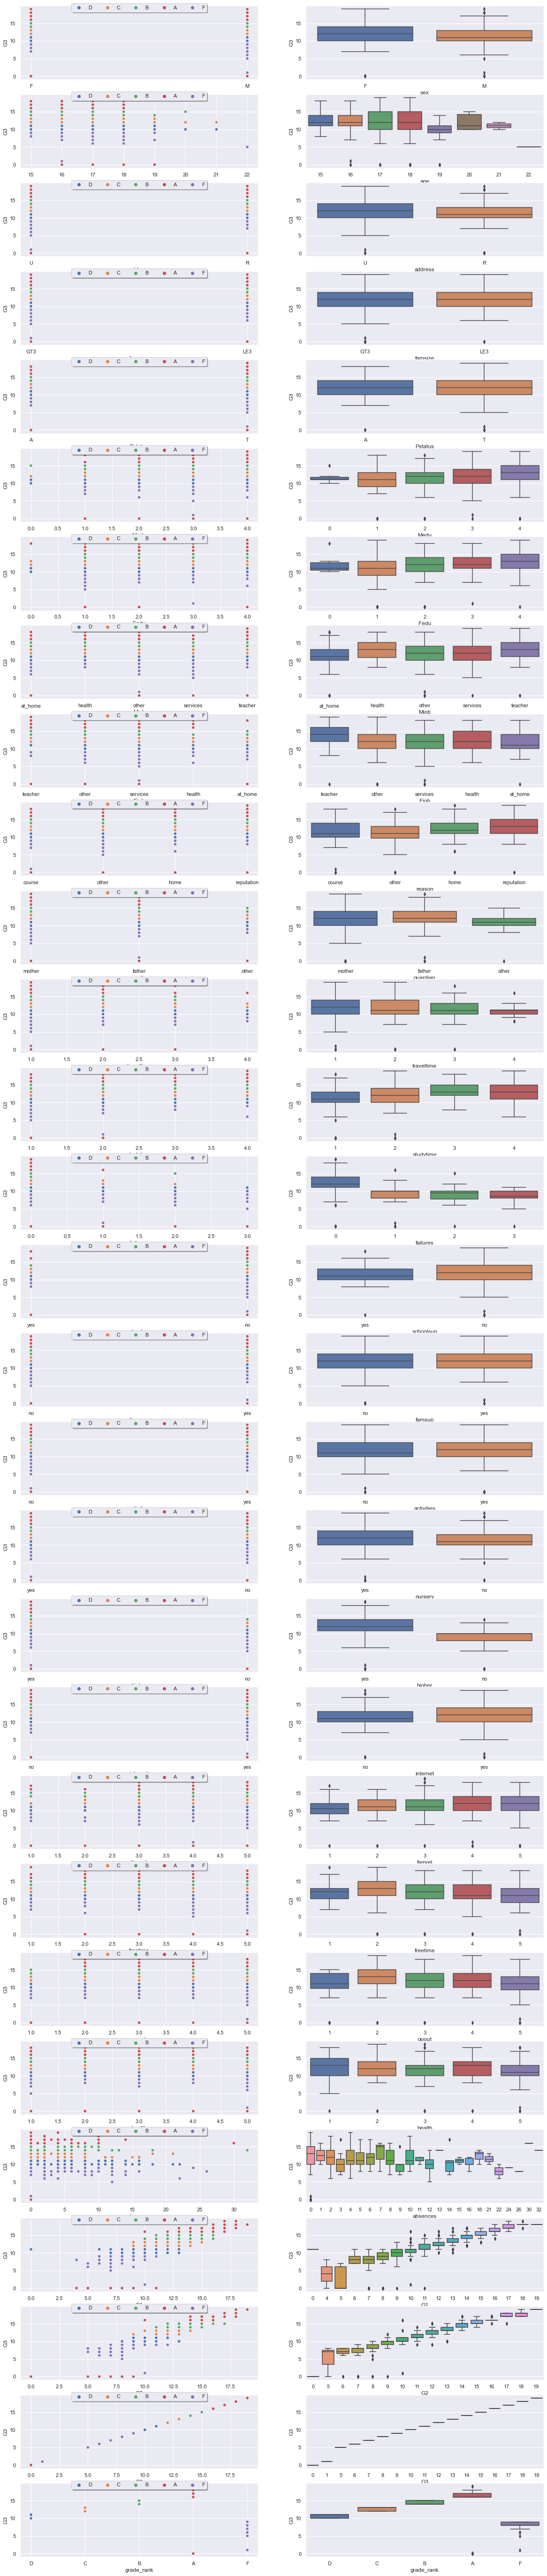

In [ ]:
plot_non_cat(new_data)

In [ ]:
data.head()

,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,activities,nursery,higher,internet,famrel,freetime,goout,health,absences,G1,G2,G3,grade_rank
0,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,yes,yes,no,4,3,4,3,4,0,11,11,D
1,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,yes,yes,5,3,3,3,2,9,11,11,D
2,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,0,yes,no,no,yes,yes,yes,4,3,2,3,6,12,13,12,C
3,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,yes,yes,yes,yes,3,2,2,5,0,14,14,14,B
4,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,no,yes,yes,no,4,3,2,5,0,11,13,13,C


C:\Users\Abraham T Owos\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


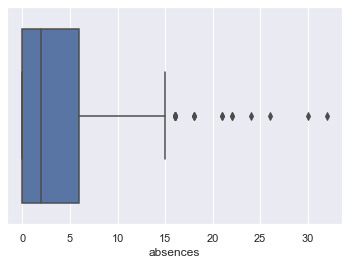

In [ ]:
sns.boxplot(data['absences'])

In [ ]:
# removing outliers by capping
from feature_engine import outliers as outr
capper = outr.Winsorizer(capping_method='gaussian', variables=['age', 'absences', 'G1', 'G2', 'G3', 'grade_rank'])
nn_data= capper.fit_transform(new_data)
nn_data.head()

,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,activities,nursery,higher,internet,famrel,freetime,goout,health,absences,G1,G2,G3,grade_rank
0,0,18.0,1,0,0,4,4,0,4,0,1,2,2,0,1,0,0,1,1,0,4,3,4,3,4.0,0.0,11.0,11.0,3.0
1,0,17.0,1,0,1,1,1,0,2,0,0,1,2,0,0,1,0,0,1,1,5,3,3,3,2.0,9.0,11.0,11.0,3.0
2,0,15.0,1,1,1,1,1,0,2,2,1,1,2,0,1,0,0,1,1,1,4,3,2,3,6.0,12.0,13.0,12.0,2.0
3,0,15.0,1,0,1,4,2,1,3,1,1,1,3,0,0,1,1,1,1,1,3,2,2,5,0.0,14.0,14.0,14.0,1.0
4,0,16.0,1,0,1,3,3,2,2,1,0,1,2,0,0,1,0,1,1,0,4,3,2,5,0.0,11.0,13.0,13.0,2.0


C:\Users\Abraham T Owos\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


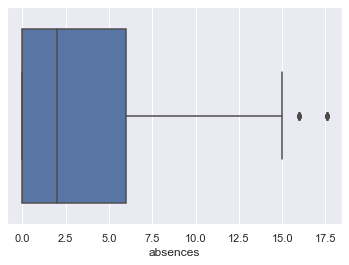

In [ ]:
sns.boxplot(nn_data['absences'])

In [ ]:
#poly nomial features
# age, g1, g2,
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(interaction_only=True)
poly_cols =['age', 'G1', 'G2']

poly1= poly.fit_transform(nn_data[poly_cols])
poly1_df = pd.DataFrame(poly1, columns=[f'poly1_{o}' for o in range(poly1.shape[1])])
poly_data = pd.concat([nn_data, poly1_df], axis=1)
poly_data.head()

,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,activities,nursery,higher,internet,famrel,freetime,goout,health,absences,G1,G2,G3,grade_rank,poly1_0,poly1_1,poly1_2,poly1_3,poly1_4,poly1_5,poly1_6
0,0,18.0,1,0,0,4,4,0,4,0,1,2,2,0,1,0,0,1,1,0,4,3,4,3,4.0,0.0,11.0,11.0,3.0,1.0,18.0,0.0,11.0,0.0,198.0,0.0
1,0,17.0,1,0,1,1,1,0,2,0,0,1,2,0,0,1,0,0,1,1,5,3,3,3,2.0,9.0,11.0,11.0,3.0,1.0,17.0,9.0,11.0,153.0,187.0,99.0
2,0,15.0,1,1,1,1,1,0,2,2,1,1,2,0,1,0,0,1,1,1,4,3,2,3,6.0,12.0,13.0,12.0,2.0,1.0,15.0,12.0,13.0,180.0,195.0,156.0
3,0,15.0,1,0,1,4,2,1,3,1,1,1,3,0,0,1,1,1,1,1,3,2,2,5,0.0,14.0,14.0,14.0,1.0,1.0,15.0,14.0,14.0,210.0,210.0,196.0
4,0,16.0,1,0,1,3,3,2,2,1,0,1,2,0,0,1,0,1,1,0,4,3,2,5,0.0,11.0,13.0,13.0,2.0,1.0,16.0,11.0,13.0,176.0,208.0,143.0


In [ ]:
poly_data.columns

Index(['sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob',
       'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures',
       'schoolsup', 'famsup', 'activities', 'nursery', 'higher', 'internet',
       'famrel', 'freetime', 'goout', 'health', 'absences', 'G1', 'G2', 'G3',
       'grade_rank', 'poly1_0', 'poly1_1', 'poly1_2', 'poly1_3', 'poly1_4',
       'poly1_5', 'poly1_6'],
      dtype='object')

In [ ]:
# First we need to know which columns are binary, nominal and numerical
def get_columns_by_category():
    categorical_mask = poly_data.select_dtypes(
        include=['object']).apply(pd.Series.nunique) == 2
    numerical_mask = poly_data.select_dtypes(
        include=['int64', 'float64']).apply(pd.Series.nunique) > 5

    binary_columns = poly_data[categorical_mask.index[categorical_mask]].columns
    nominal_columns = poly_data[categorical_mask.index[~categorical_mask]].columns
    numerical_columns = poly_data[numerical_mask.index[numerical_mask]].columns

    return binary_columns, nominal_columns, numerical_columns

In [ ]:
binary_columns, nominal_columns, numerical_columns = get_columns_by_category()

In [ ]:
from sklearn.linear_model import LogisticRegressionCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split, cross_val_score
from sklearn.metrics import log_loss, f1_score, classification_report, precision_score, recall_score
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline

In [ ]:
# Now we can create a column transformer pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
transformers = [('binary', OrdinalEncoder(), binary_columns),
                ('nominal', OneHotEncoder(), nominal_columns),
                ('numerical', StandardScaler(), numerical_columns)]

transformer_pipeline = ColumnTransformer(transformers, remainder='passthrough')

In [ ]:
# Starified k cross validation
Kfold = StratifiedKFold(n_splits=5)

In [ ]:
RANDOM_STATE = 42
from sklearn.linear_model import LogisticRegression
# I did tweak some of the hyperparameters with trial & error
classifiers = [LogisticRegression(max_iter=70, solver='sag', random_state=RANDOM_STATE),
               DecisionTreeClassifier(max_depth=2, random_state=RANDOM_STATE),
               SVC(C=2, kernel='linear', random_state=RANDOM_STATE),
               RandomForestClassifier(
                   max_depth=7, min_samples_split=5, min_samples_leaf=5, random_state=RANDOM_STATE),
               AdaBoostClassifier(DecisionTreeClassifier(
                   max_depth=1, random_state=RANDOM_STATE), random_state=RANDOM_STATE),
               GradientBoostingClassifier(
                   learning_rate=0.005, n_estimators=30, random_state=RANDOM_STATE),
               KNeighborsClassifier(),
               GaussianNB(var_smoothing=1e-2)
               ]

In [ ]:
classifiers_names = ['Logistic Regression',
                     'Decision Tree Classifier',
                     'Support Vector Machine',
                     'Random Forest Classifier',
                     'AdaBoost Classifier',
                     'Gradient Boosting Classifier',
                     'K Neighbors Classifier',
                     'Gaussian Naive Bayes'
                     ]

pipelines = [Pipeline([('transformer', transformer_pipeline), (classifier_name, classifier)])
             for classifier_name, classifier in zip(classifiers_names, classifiers)]

In [ ]:
scoring = {'acc': 'accuracy'}


In [ ]:
poly_data.columns

Index(['sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob',
       'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures',
       'schoolsup', 'famsup', 'activities', 'nursery', 'higher', 'internet',
       'famrel', 'freetime', 'goout', 'health', 'absences', 'G1', 'G2', 'G3',
       'grade_rank', 'poly1_0', 'poly1_1', 'poly1_2', 'poly1_3', 'poly1_4',
       'poly1_5', 'poly1_6'],
      dtype='object')

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
        poly_data.drop(['grade_rank'], axis=1), poly_data['grade_rank'],
        test_size=.2, random_state=2022
        )

In [ ]:
def cv_fit_models():
    train_acc_results = []
    cv_scores = {classifier_name: [] for classifier_name in classifiers_names}
    for classifier_name, pipeline in zip(classifiers_names, pipelines):
        cv_score = cross_validate(pipeline,
                                  X_train,
                                  y_train,
                                  scoring=scoring,
                                  cv=Kfold,
                                  return_train_score=True,
                                  return_estimator=True)

        train_accuracy = cv_score['train_acc'].mean() * 100

        train_acc_results.append(train_accuracy)
        cv_scores[classifier_name].append(cv_score)

    return np.array(train_acc_results), cv_scores

In [ ]:
X_train.columns

Index(['sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob',
       'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures',
       'schoolsup', 'famsup', 'activities', 'nursery', 'higher', 'internet',
       'famrel', 'freetime', 'goout', 'health', 'absences', 'G1', 'G2', 'G3',
       'poly1_0', 'poly1_1', 'poly1_2', 'poly1_3', 'poly1_4', 'poly1_5',
       'poly1_6'],
      dtype='object')

In [ ]:
results, folds_scores = cv_fit_models()

C:\Users\Abraham T Owos\anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:328: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn("The max_iter was reached which means "
C:\Users\Abraham T Owos\anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:328: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn("The max_iter was reached which means "
C:\Users\Abraham T Owos\anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:328: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn("The max_iter was reached which means "
C:\Users\Abraham T Owos\anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:328: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn("The max_iter was reached which means "
C:\Users\Abraham T Owos\anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:328: Convergenc

In [ ]:
#scaling
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
# scaling only the contineous variable
scaled_poly_cont = poly_data.copy()
scaled_poly_cont[['age', 'G1', 'G2',
        'poly1_0', 'poly1_1', 'poly1_2', 'poly1_3', 'poly1_4',
       'poly1_5', 'poly1_6']] = scaler.fit_transform(scaled_poly_cont[['age', 'G1', 'G2',
        'poly1_0', 'poly1_1', 'poly1_2', 'poly1_3', 'poly1_4',
       'poly1_5', 'poly1_6']])

#the whole data
scaled_poly_all = poly_data.copy()
cols = scaled_poly_all.drop(['G3', 'grade_rank'], axis=1).columns
scaled_poly_all[cols] = scaler.fit_transform(scaled_poly_all[cols])
scaled_poly_cont.head()

,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,activities,nursery,higher,internet,famrel,freetime,goout,health,absences,G1,G2,G3,grade_rank,poly1_0,poly1_1,poly1_2,poly1_3,poly1_4,poly1_5,poly1_6
0,0,0.555696,1,0,0,4,4,0,4,0,1,2,2,0,1,0,0,1,1,0,4,3,4,3,4.0,0.000000,0.578947,11.0,3.0,0.0,0.555696,0.000000,0.578947,0.000000,0.611111,0.000000
1,0,0.370464,1,0,1,1,1,0,2,0,0,1,2,0,0,1,0,0,1,1,5,3,3,3,2.0,0.473684,0.578947,11.0,3.0,0.0,0.370464,0.473684,0.578947,0.447368,0.577160,0.289474
2,0,0.000000,1,1,1,1,1,0,2,2,1,1,2,0,1,0,0,1,1,1,4,3,2,3,6.0,0.631579,0.684211,12.0,2.0,0.0,0.000000,0.631579,0.684211,0.526316,0.601852,0.456140
3,0,0.000000,1,0,1,4,2,1,3,1,1,1,3,0,0,1,1,1,1,1,3,2,2,5,0.0,0.736842,0.736842,14.0,1.0,0.0,0.000000,0.736842,0.736842,0.614035,0.648148,0.573099
4,0,0.185232,1,0,1,3,3,2,2,1,0,1,2,0,0,1,0,1,1,0,4,3,2,5,0.0,0.578947,0.684211,13.0,2.0,0.0,0.185232,0.578947,0.684211,0.514620,0.641975,0.418129


In [ ]:
def pick_best_estimator():
    best_estimators = {classifier_name: [] for classifier_name in classifiers_names}
    for key, model in folds_scores.items():
        best_acc_idx = np.argmax(model[0]['test_acc'])
        best_model = model[0]['estimator'][best_acc_idx]
        best_estimators[key].append(best_model)
    return best_estimators

In [ ]:
best_estimators = pick_best_estimator()

In [ ]:
def gather_metrics_scores():
    test_accs, precisions, recalls = [], [], []
    for estimator_val in best_estimators.values():
        estimator = estimator_val[0]
        y_pred = estimator.predict(X_test)
        precision = precision_score(y_test, y_pred, average='weighted')
        recall = recall_score(y_test, y_pred, average='weighted')
        score = estimator.score(X_test, y_test)

        test_accs.append(score)
        precisions.append(precision)
        recalls.append(recall)

    scores = {'test_acc': np.array(test_accs),
              'precision': np.array(precisions),
              'recall': np.array(recalls)}

    return scores

In [ ]:
scores = gather_metrics_scores()

C:\Users\Abraham T Owos\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1248: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\Abraham T Owos\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1248: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\Abraham T Owos\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1248: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [ ]:
def plot_train_test_accuracy(df):
    _, ax = plt.subplots(nrows=2, ncols=1, figsize=(15, 15))
    sns.barplot(data=df, x='train_accuracy',
                y='Model', orient='h', ax=ax[0])
    ax[0].set_xlim([0, 100])
    sns.barplot(data=df, x='test_accuracy',
                y='Model', orient='h', ax=ax[1])
    ax[1].set_xlim([0, 100])

In [ ]:
results_df = pd.DataFrame({'Model': classifiers_names,
                           'train_accuracy': results,
                           'test_accuracy': scores['test_acc'] * 100,
                           'test_precision': scores['precision'] * 100,
                           'test_recall': scores['recall'] * 100})

In [ ]:
results_df.head()

,Model,train_accuracy,test_accuracy,test_precision,test_recall
0,Logistic Regression,72.061747,58.461538,56.773269,58.461538
1,Decision Tree Classifier,85.163809,84.615385,75.316239,84.615385
2,Support Vector Machine,95.231233,90.000000,90.671028,90.000000
3,Random Forest Classifier,95.905816,86.923077,87.261072,86.923077
4,AdaBoost Classifier,68.978916,72.307692,53.548189,72.307692


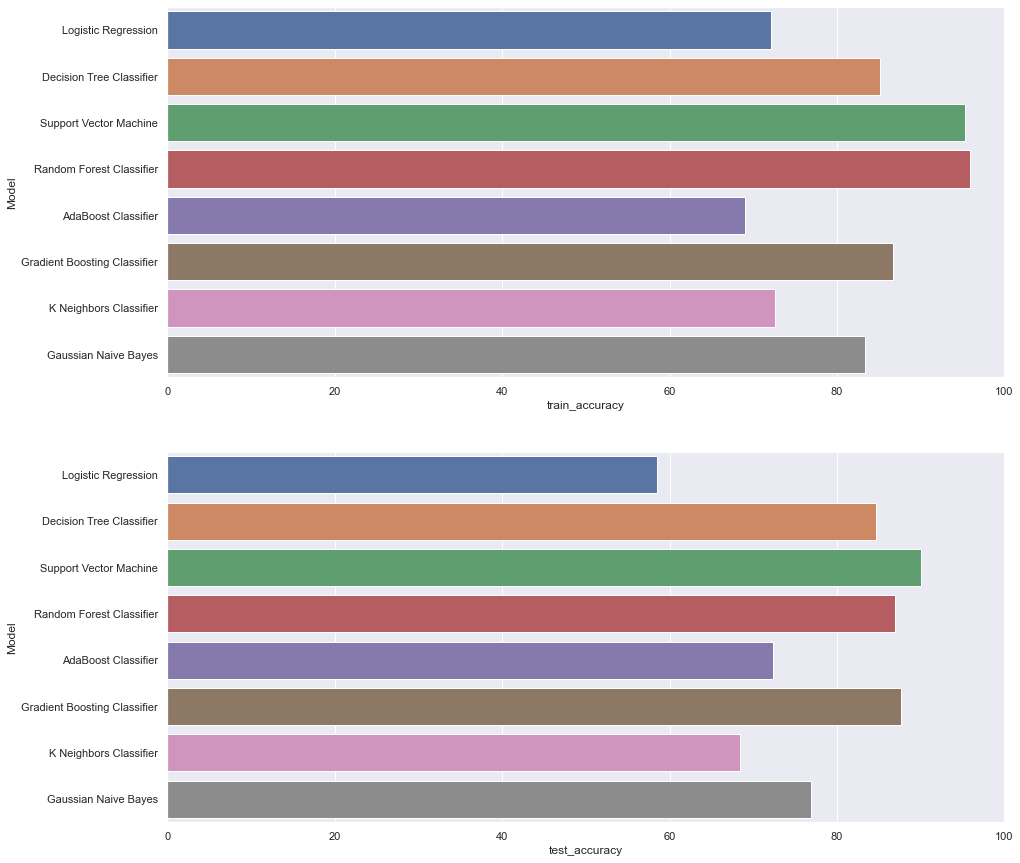

In [ ]:
plot_train_test_accuracy(results_df)

In [ ]:
scaled_poly_cont.to_csv('scaled_poly_cont.csv', index=False)
scaled_poly_all.to_csv('scaled_poly_all.csv', index=False)

## MOdeling

In [ ]:
from sklearn.linear_model import LogisticRegressionCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, train_test_split, cross_val_score
from sklearn.metrics import log_loss, f1_score, classification_report
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

In [ ]:
#modeler
def modeler (data, model):
    X_train, X_test, y_train, y_test = train_test_split(
        data.drop(['G3', 'grade_rank'], axis=1), data['grade_rank'],
        test_size=.2, random_state=2022
        )
    model
    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    print(f1_score(pred, y_test, average='weighted'))
    print(classification_report(pred, y_test))

In [ ]:
modeler(data=scaled_poly_cont, model= LogisticRegressionCV())
modeler(data=scaled_poly_all, model= LogisticRegressionCV())

LogisticRegressionCV()


C:\Users\Abraham T Owos\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:763: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\Abraham T Owos\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:763: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-re

In [ ]:
modeler(data=scaled_poly_cont, model= DecisionTreeClassifier())
modeler(data=scaled_poly_all, model= DecisionTreeClassifier())

0.6490883984923355
              precision    recall  f1-score   support

         0.0       0.70      0.82      0.76        17
         1.0       0.45      0.43      0.44        21
         2.0       0.67      0.69      0.68        32
         3.0       0.71      0.76      0.73        38
         4.0       0.69      0.50      0.58        22

    accuracy                           0.65       130
   macro avg       0.64      0.64      0.64       130
weighted avg       0.65      0.65      0.65       130

0.6818349020880666
              precision    recall  f1-score   support

         0.0       0.70      0.88      0.78        16
         1.0       0.45      0.45      0.45        20
         2.0       0.70      0.70      0.70        33
         3.0       0.73      0.79      0.76        38
         4.0       0.81      0.57      0.67        23

    accuracy                           0.68       130
   macro avg       0.68      0.68      0.67       130
weighted avg       0.69      0.68      

In [ ]:
modeler(data=scaled_poly_cont, model= RandomForestClassifier())
modeler(data=scaled_poly_all, model= RandomForestClassifier())

0.7046329807704935
              precision    recall  f1-score   support

         0.0       0.65      1.00      0.79        13
         1.0       0.70      0.54      0.61        26
         2.0       0.67      0.73      0.70        30
         3.0       0.83      0.76      0.79        45
         4.0       0.56      0.56      0.56        16

    accuracy                           0.71       130
   macro avg       0.68      0.72      0.69       130
weighted avg       0.72      0.71      0.70       130

0.7352132181543947
              precision    recall  f1-score   support

         0.0       0.65      1.00      0.79        13
         1.0       0.60      0.55      0.57        22
         2.0       0.76      0.71      0.74        35
         3.0       0.83      0.83      0.83        41
         4.0       0.75      0.63      0.69        19

    accuracy                           0.74       130
   macro avg       0.72      0.74      0.72       130
weighted avg       0.74      0.74      

In [ ]:
modeler(data=scaled_poly_all, model= GaussianNB())

0.705073824048183
              precision    recall  f1-score   support

         0.0       0.60      0.92      0.73        13
         1.0       0.65      0.54      0.59        24
         2.0       0.67      0.69      0.68        32
         3.0       0.78      0.80      0.79        40
         4.0       0.81      0.62      0.70        21

    accuracy                           0.71       130
   macro avg       0.70      0.71      0.70       130
weighted avg       0.72      0.71      0.71       130



In [ ]:
modeler(data=scaled_poly_all, model= SVC())

0.6012594632244289
              precision    recall  f1-score   support

         0.0       0.35      0.88      0.50         8
         1.0       0.40      0.42      0.41        19
         2.0       0.58      0.59      0.58        32
         3.0       0.88      0.60      0.71        60
         4.0       0.38      0.55      0.44        11

    accuracy                           0.58       130
   macro avg       0.52      0.61      0.53       130
weighted avg       0.66      0.58      0.60       130



In [ ]:
modeler(data=scaled_poly_all, model= CatBoostClassifier())

Learning rate set to 0.076524
0:	learn: 1.5299894	total: 35.1ms	remaining: 35s
1:	learn: 1.4489261	total: 61.8ms	remaining: 30.9s
2:	learn: 1.3674610	total: 84.9ms	remaining: 28.2s
3:	learn: 1.2953228	total: 137ms	remaining: 34.1s
4:	learn: 1.2399842	total: 163ms	remaining: 32.5s
5:	learn: 1.1898569	total: 202ms	remaining: 33.4s
6:	learn: 1.1525998	total: 223ms	remaining: 31.6s
7:	learn: 1.1096244	total: 242ms	remaining: 30s
8:	learn: 1.0592788	total: 262ms	remaining: 28.9s
9:	learn: 1.0285545	total: 281ms	remaining: 27.9s
10:	learn: 0.9931949	total: 299ms	remaining: 26.9s
11:	learn: 0.9645548	total: 348ms	remaining: 28.6s
12:	learn: 0.9406387	total: 373ms	remaining: 28.3s
13:	learn: 0.9139708	total: 409ms	remaining: 28.8s
14:	learn: 0.8932304	total: 435ms	remaining: 28.6s
15:	learn: 0.8709031	total: 456ms	remaining: 28s
16:	learn: 0.8529975	total: 487ms	remaining: 28.2s
17:	learn: 0.8372096	total: 516ms	remaining: 28.2s
18:	learn: 0.8172105	total: 544ms	remaining: 28.1s
19:	learn: 0.8

In [ ]:
modeler(data=scaled_poly_all, model= XGBClassifier(scale_pos_weight = 8,max_depth = 8, n_estimators = 500))

C:\Users\Abraham T Owos\anaconda3\lib\site-packages\xgboost\sklearn.py:1146: UserWarning: The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].
  warnings.warn(label_encoder_deprecation_msg, UserWarning)


[12:25:42] WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.4.0/src/learner.cc:573: 
Parameters: { "scale_pos_weight" } might not be used.

  This may not be accurate due to some parameters are only used in language bindings but
  passed down to XGBoost core.  Or some parameters are not used but slip through this
  verification. Please open an issue if you find above cases.


[12:25:42] WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.4.0/src/learner.cc:1095: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'multi:softprob' was changed from 'merror' to 'mlogloss'. Explicitly set eval_metric if you'd like to restore the old behavior.
0.7463865120971704
              precision    recall  f1-score   support

         0.0       0.80      0.84      0.82        19
         1.0       0.65      0.59      0.62        22
         2.0       0.70      0.79      0.74        29
         3.0       0.85      0.78      0.81        45
   

In [ ]:
modeler(data=scaled_poly_all, model= LGBMClassifier(scale_pos_weight = 1,max_depth=6, n_estimators = 1000, learning_rate=0.01))

0.7121227609599702
              precision    recall  f1-score   support

         0.0       0.75      1.00      0.86        15
         1.0       0.60      0.50      0.55        24
         2.0       0.64      0.70      0.67        30
         3.0       0.85      0.78      0.81        45
         4.0       0.62      0.62      0.62        16

    accuracy                           0.72       130
   macro avg       0.69      0.72      0.70       130
weighted avg       0.72      0.72      0.71       130



## Modeling focus
* logreg + fullscaling -0.7104
* randomforest + fullscaing - 0.7370
* catboost + fullscaling - 0.7296
* Xgboost + fullscaling - 0.7296
* LGBClassifier + fullscaling -0.6936

## Hyperparameter Tunning

In [ ]:
import optuna
def objective(trial):
    classifier = trial.suggest_categorical('classifier', ['logreg', 'randomf', 'catb', 'xgb', 'lgb'])

    if classifier == 'logreg':
        penalty = trial.suggest_categorical('penalty', ['l1', 'l2', 'elasticnet'])
        max_iter = trial.suggest_int('max_iter', 100, 200)

        clf = LogisticRegressionCV(penalty=penalty, max_iter=max_iter)
    '''
    elif classifier == 'randomf':
        n_estimator = trial.suggest_int('n_estimator', 100, 2000)
        criterion = trial.suggest_categorical('criterion', ['gini', 'entropy'])
        min_samples_split = trial.suggest_int('min_samples_split', 2, 10)
        min_samples_leaf = trial.suggest_int('min_samples_leaf', 2, 10)
        min_weight_fraction_leaf = trial.suggest_float('min_weight_fraction_leaf', 0.0, 1.0)
        bootstrap = trial.suggest_categorical('bootstrap', [True, False])

        clf = RandomForestClassifier(n_estimator=n_estimator, criterion=criterion, min_samples_leaf=min_samples_leaf, min_samples_split=min_samples_split
                                     min_weight_fraction_leaf=min_weight_fraction_leaf, bootstrap=bootstrap)

    elif classifier == 'catb':
        param = {}
        param['learning_rate'] = trial.suggest_discrete_uniform("learning_rate", 0.001, 0.1, 0.001)
        param['depth'] = trial.suggest_int('depth', 3, 15)
        param['l2_leaf_reg'] = trial.suggest_discrete_uniform('l2_leaf_reg', 1.0, 5.5, 0.5)
        param['min_child_samples'] = trial.suggest_categorical('min_child_samples', [1, 4, 8, 16, 32])
        param['iterations'] = trial.suggest_discrete_uniform("iterations", 200, 2000, 50)
        param['use_best_model'] = True
        param["colsample_bylevel"] =  trial.suggest_float("colsample_bylevel", 0.01, 0.1)
        param['random_state'] = 0
        param['scale_pos_weight'] = trial.suggest_int('scale_pos_weight', 1, 10)
        param['bootstrap_type'] = trial.suggest_categorical("bootstrap_type", ["Bayesian", "Bernoulli", "MVS"])
        param['logging_level'] = 'Silent'

        clf = CatBoostClassifier(**param)

    elif classifier == 'xbg':
        param = {}
        param['learning_rate'] = trial.suggest_discrete_uniform("learning_rate", 0.001, 0.1, 0.001)
        param['depth'] = trial.suggest_int('depth', 3, 15)
        param['l2_leaf_reg'] = trial.suggest_discrete_uniform('l2_leaf_reg', 1.0, 5.5, 0.5)
        param['min_child_samples'] = trial.suggest_categorical('min_child_samples', [1, 4, 8, 16, 32])
        param['iterations'] = trial.suggest_discrete_uniform("iterations", 200, 2000, 50)
        param['use_best_model'] = True
        param["colsample_bylevel"] =  trial.suggest_float("colsample_bylevel", 0.01, 0.1)
        param['random_state'] = 0
        param['scale_pos_weight'] = trial.suggest_int('scale_pos_weight', 1, 10)
        param['bootstrap_type'] = trial.suggest_categorical("bootstrap_type", ["Bayesian", "Bernoulli", "MVS"])
        param['logging_level'] = 'Silent'

        clf = XGBClassifier(**param)
    elif classifier == 'lgb':
        param = {}
        param["learning_rate"] = trial.suggest_float("learning_rate", 1e-2, 0.25, log=True)
        param['subsample'] = trial.suggest_float("subsample", 0.1, 1.0)
        param['colsample_bytree'] = trial.suggest_float("colsample_bytree", 0.1, 1.0)
        param['max_depth'] = trial.suggest_int("max_depth", 5, 20)
        param['scale_pos_weight'] = trial.suggest_int('scale_pos_weight', 3, 10)'''

    return cross_val_score(clf, X_train, y_train, n_jobs = -1, cv=3).mean()












In [ ]:
#creating a study
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100)